In [1]:
!pip install shap lime matplotlib pandas scikit-learn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- ------------------------------------- 0.5/9.9 MB 376.7 kB/s eta 0:00:25
   -- -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
checkpoint = torch.load("model.pth")

print(type(checkpoint))


<class 'collections.OrderedDict'>


In [7]:
from torchvision import models
import torch.nn as nn
import torch


# Create ResNet18
model = models.resnet18()


# Change final layer for 10 classes
model.fc = nn.Linear(512, 10)


# Load your trained weights
model.load_state_dict(torch.load("model.pth"))


# Evaluation mode
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

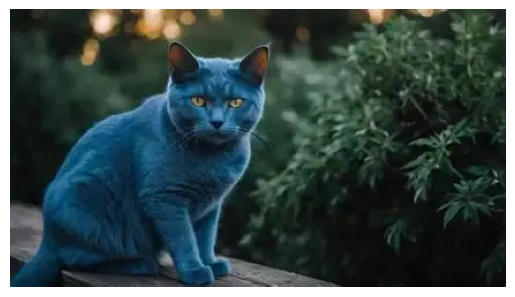

In [9]:
from PIL import Image
import matplotlib.pyplot as plt


img = Image.open("test_images/OIP (4).webp")


plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
import torchvision.transforms as transforms


transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


image_tensor = transform(img)


image_tensor = image_tensor.unsqueeze(0)


print(image_tensor.shape)

torch.Size([1, 3, 224, 224])


In [11]:
with torch.no_grad():

    output = model(image_tensor)


prediction = torch.argmax(output, dim=1)


print("Predicted class number:", prediction.item())

Predicted class number: 3


In [12]:
classes = [
    "bird",
    "bus",
    "car",
    "cat",
    "dog",
    "elephant",
    "horse",
    "lion",
    "tiger",
    "truck"
]


predicted_class = classes[prediction.item()]


print("Predicted class:", predicted_class)

Predicted class: cat


In [16]:
def predict(images):

    images = torch.tensor(images).permute(0,3,1,2).float()

    outputs = model(images)

    return outputs.detach().numpy()


In [18]:
from lime import lime_image
import numpy as np

In [19]:
explainer = lime_image.LimeImageExplainer()

In [20]:
explainer = lime_image.LimeImageExplainer()

print("LIME Ready")


LIME Ready


In [24]:
def predict(images):

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    batch = []

    for image in images:
        image = Image.fromarray(image.astype('uint8'))
        image = transform(image)
        batch.append(image)

    batch = torch.stack(batch)

    with torch.no_grad():
        outputs = model(batch)

    return outputs.numpy()

In [25]:
explanation = explainer.explain_instance(
    np.array(img.resize((224,224))),
    predict,
    top_labels=3,
    hide_color=0,
    num_samples=100
)

print("Explanation created")

100%|██████████| 100/100 [00:18<00:00,  5.52it/s]


Explanation created


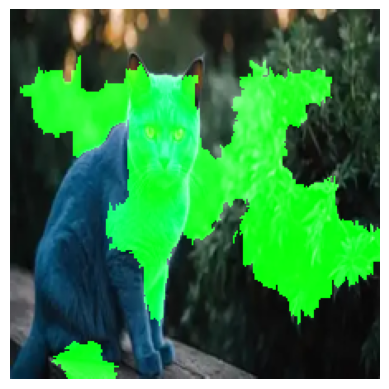

In [26]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=10,
    hide_rest=False
)

plt.imshow(temp)
plt.axis("off")
plt.show()

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt


dataset_path = "dataset"


classes = os.listdir(dataset_path)


counts = []


for cls in classes:
    path = os.path.join(dataset_path, cls)
    counts.append(len(os.listdir(path)))


data = pd.DataFrame({
    "Class": classes,
    "Images": counts
})


data

,Class,Images
0,bird,1
1,bus,1
2,car,1
3,cat,1
4,dog,1
5,elephant,1
6,horse,1
7,lion,1
8,tiger,1
9,truck,2


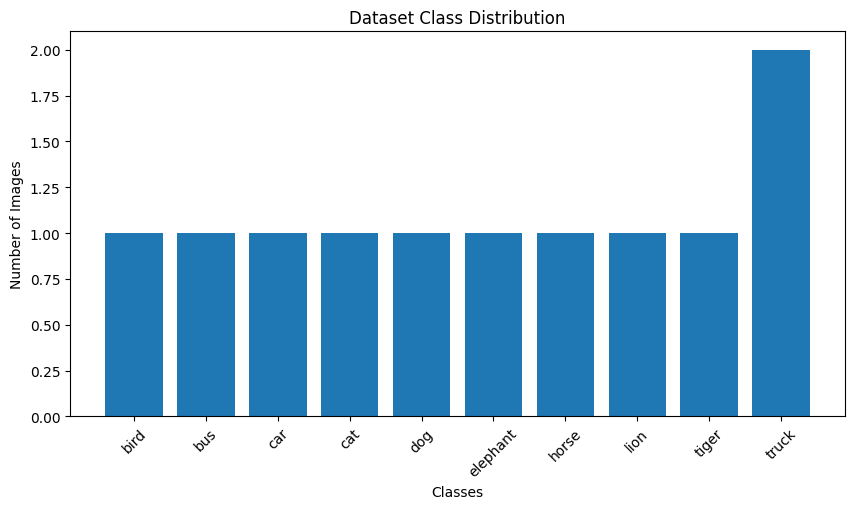

In [28]:
plt.figure(figsize=(10,5))

plt.bar(
    data["Class"],
    data["Images"]
)

plt.xticks(rotation=45)

plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.title("Dataset Class Distribution")

plt.show()

## Bias Analysis Findings

The dataset was analyzed to check class distribution across the 10 categories:
bird, bus, car, cat, dog, elephant, horse, lion, tiger, and truck.

The class distribution graph shows whether some classes contain more images than others.

If some classes have fewer images, the model may learn those classes less effectively, which can create performance bias.

Since the dataset does not contain sensitive attributes such as gender, age, or ethnicity, demographic fairness analysis was not applicable.

The analysis focused on class imbalance and equal performance across image categories.

## Bias Mitigation Recommendations

1. Increase Dataset Diversity:
Collect more images for classes with fewer samples.

2. Data Augmentation:
Apply image transformations such as:
- rotation
- flipping
- brightness adjustment
- cropping

to create more diverse training examples.

3. Balanced Training:
Use class weights or balanced sampling so that underrepresented classes receive proper importance during training.

4. Model Evaluation:
Monitor accuracy, precision, recall, and F1-score for each class instead of only overall accuracy.

5. Continuous Monitoring:
After deployment, regularly check model performance to detect new bias issues.